# Deep Patch Cancer Classifier

Train and evaluate deep neural networks on the existing patch dataset in `data/patches`.

Labels:

- `outside` = non-cancer / background patch = class `0`
- `inside` = cancer / tumor patch = class `1`

This notebook is self-contained for the main CNN baseline: it uses PyTorch, PIL, NumPy, and Matplotlib only. The optional ResNet transfer-learning section is guarded so it skips cleanly if `torchvision` is not installed.

In [2]:
from pathlib import Path
import copy
import json
import math
import os
import random
import time
from collections import Counter

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-kbcc")

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image, ImageEnhance
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
import matplotlib.pyplot as plt

SEED = 42
DATA_ROOT = Path("data/patches")
OUT_DIR = Path("results/deep_patch_cnn")
OUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = 128
BATCH_SIZE = 64
NUM_WORKERS = 0
EPOCHS = 25
PATIENCE = 6
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
RUN_FULL_TRAINING = True
RUN_RESNET_TRANSFER = False

CLASS_TO_IDX = {"outside": 0, "inside": 1}
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}
EXPECTED_COUNTS = {
    "train": {"inside": 2900, "outside": 3430},
    "val": {"inside": 1080, "outside": 790},
    "test": {"inside": 1040, "outside": 830},
}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Dataset root: {DATA_ROOT.resolve()}")
print(f"Output dir:   {OUT_DIR.resolve()}")

Using device: cuda
Dataset root: /home/masoud/Projects/Kernel_Based_Cancer_Classification/data/patches
Output dir:   /home/masoud/Projects/Kernel_Based_Cancer_Classification/results/deep_patch_cnn


In [3]:
IMAGE_EXTENSIONS = {".tif", ".tiff", ".png", ".jpg", ".jpeg"}


def pil_to_rgb_tensor(image):
    image = image.convert("RGB")
    arr = np.asarray(image, dtype=np.float32) / 255.0
    tensor = torch.from_numpy(arr).permute(2, 0, 1)
    return tensor


def normalize_tensor(x):
    mean = torch.tensor([0.485, 0.456, 0.406], dtype=x.dtype).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], dtype=x.dtype).view(3, 1, 1)
    return (x - mean) / std


def denormalize_tensor(x):
    mean = torch.tensor([0.485, 0.456, 0.406], dtype=x.dtype, device=x.device).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], dtype=x.dtype, device=x.device).view(3, 1, 1)
    return (x * std + mean).clamp(0, 1)


def augment_image(image):
    if random.random() < 0.5:
        image = image.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
    if random.random() < 0.5:
        image = image.transpose(Image.Transpose.FLIP_TOP_BOTTOM)
    k = random.randint(0, 3)
    if k:
        image = image.rotate(90 * k)
    if random.random() < 0.35:
        image = ImageEnhance.Brightness(image).enhance(random.uniform(0.85, 1.15))
    if random.random() < 0.35:
        image = ImageEnhance.Contrast(image).enhance(random.uniform(0.85, 1.15))
    return image


class PatchDataset(Dataset):
    def __init__(self, root, split, augment=False):
        self.root = Path(root)
        self.split = split
        self.augment = augment
        self.samples = []
        for class_name, label in CLASS_TO_IDX.items():
            class_dir = self.root / split / class_name
            if not class_dir.exists():
                raise FileNotFoundError(f"Missing class directory: {class_dir}")
            files = sorted(p for p in class_dir.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS)
            self.samples.extend((p, label) for p in files)
        if not self.samples:
            raise RuntimeError(f"No image patches found under {self.root / split}")
        self.labels = [label for _, label in self.samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        with Image.open(path) as image:
            image = image.convert("RGB")
            if image.size != (IMAGE_SIZE, IMAGE_SIZE):
                image = image.resize((IMAGE_SIZE, IMAGE_SIZE), Image.Resampling.BILINEAR)
            if self.augment:
                image = augment_image(image)
            x = normalize_tensor(pil_to_rgb_tensor(image))
        return x, torch.tensor(label, dtype=torch.long)


def make_loader(dataset, batch_size=BATCH_SIZE, balanced=False, shuffle=False):
    sampler = None
    if balanced:
        counts = Counter(dataset.labels)
        sample_weights = [1.0 / counts[label] for label in dataset.labels]
        sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=(shuffle and sampler is None),
        sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )


train_ds = PatchDataset(DATA_ROOT, "train", augment=True)
val_ds = PatchDataset(DATA_ROOT, "val", augment=False)
test_ds = PatchDataset(DATA_ROOT, "test", augment=False)

train_eval_ds = PatchDataset(DATA_ROOT, "train", augment=False)

train_loader = make_loader(train_ds, balanced=True)
train_eval_loader = make_loader(train_eval_ds, shuffle=False)
val_loader = make_loader(val_ds, shuffle=False)
test_loader = make_loader(test_ds, shuffle=False)

for split, ds in [("train", train_ds), ("val", val_ds), ("test", test_ds)]:
    counts_by_idx = Counter(ds.labels)
    counts = {IDX_TO_CLASS[idx]: counts_by_idx.get(idx, 0) for idx in sorted(IDX_TO_CLASS)}
    print(f"{split:5s}: total={len(ds):5d} counts={counts}")
    expected = EXPECTED_COUNTS[split]
    assert counts == expected, f"Unexpected {split} counts: got {counts}, expected {expected}"

xb, yb = next(iter(train_loader))
print("One train batch:", tuple(xb.shape), tuple(yb.shape), "labels:", yb[:12].tolist())
assert tuple(xb.shape[1:]) == (3, IMAGE_SIZE, IMAGE_SIZE)

train: total= 6330 counts={'outside': 3430, 'inside': 2900}
val  : total= 1870 counts={'outside': 790, 'inside': 1080}
test : total= 1870 counts={'outside': 830, 'inside': 1040}
One train batch: (64, 3, 128, 128) (64,) labels: [0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1]


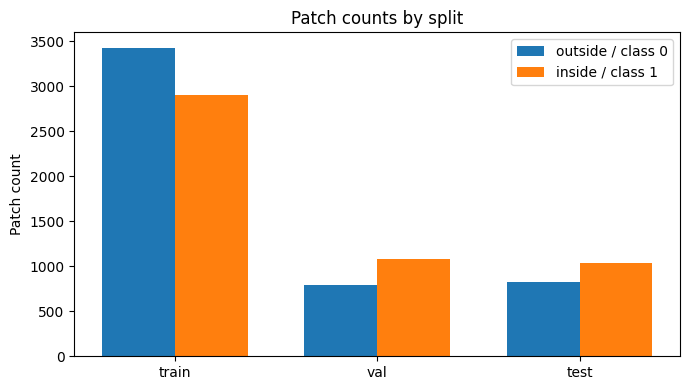

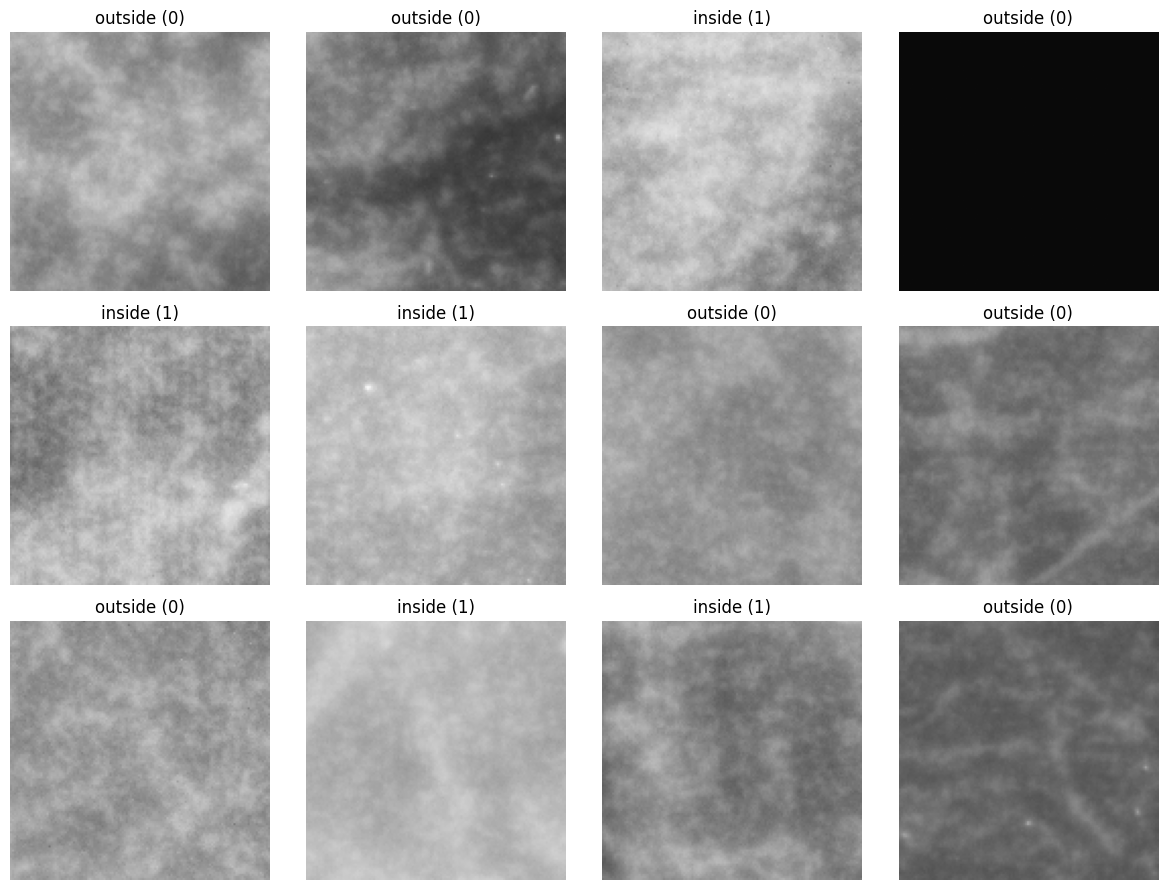

In [4]:
def plot_class_counts(datasets):
    splits = list(datasets.keys())
    inside = [Counter(datasets[s].labels)[CLASS_TO_IDX["inside"]] for s in splits]
    outside = [Counter(datasets[s].labels)[CLASS_TO_IDX["outside"]] for s in splits]
    x = np.arange(len(splits))
    width = 0.36
    plt.figure(figsize=(7, 4))
    plt.bar(x - width / 2, outside, width, label="outside / class 0")
    plt.bar(x + width / 2, inside, width, label="inside / class 1")
    plt.xticks(x, splits)
    plt.ylabel("Patch count")
    plt.title("Patch counts by split")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / "class_counts.png", dpi=160)
    plt.show()


def show_sample_patches(dataset, n=12):
    rng = np.random.default_rng(SEED)
    idxs = rng.choice(len(dataset), size=min(n, len(dataset)), replace=False)
    cols = 4
    rows = math.ceil(len(idxs) / cols)
    plt.figure(figsize=(cols * 3, rows * 3))
    for i, idx in enumerate(idxs, start=1):
        x, y = dataset[int(idx)]
        img = denormalize_tensor(x).permute(1, 2, 0).numpy()
        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.title(f"{IDX_TO_CLASS[int(y)]} ({int(y)})")
        plt.axis("off")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "sample_patches.png", dpi=160)
    plt.show()


plot_class_counts({"train": train_eval_ds, "val": val_ds, "test": test_ds})
show_sample_patches(train_eval_ds, n=12)

In [5]:
def confusion_counts(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    return {"tn": tn, "fp": fp, "fn": fn, "tp": tp}


def roc_curve_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    positives = int((y_true == 1).sum())
    negatives = int((y_true == 0).sum())
    if positives == 0 or negatives == 0:
        return np.array([0.0, 1.0]), np.array([0.0, 1.0]), float("nan")
    order = np.argsort(-y_score)
    y_sorted = y_true[order]
    tps = np.cumsum(y_sorted == 1)
    fps = np.cumsum(y_sorted == 0)
    tpr = np.r_[0.0, tps / positives, 1.0]
    fpr = np.r_[0.0, fps / negatives, 1.0]
    auc = float(np.trapz(tpr, fpr))
    return fpr, tpr, auc


def classification_metrics(y_true, y_pred, y_score):
    c = confusion_counts(y_true, y_pred)
    tn, fp, fn, tp = c["tn"], c["fp"], c["fn"], c["tp"]
    total = max(tn + fp + fn + tp, 1)
    accuracy = (tp + tn) / total
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    fpr, tpr, auc = roc_curve_auc(y_true, y_score)
    return {
        "loss": None,
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "roc_auc": float(auc),
        "confusion": c,
        "fpr": fpr,
        "tpr": tpr,
    }


# Metric smoke test without sklearn.
_smoke = classification_metrics([0, 0, 1, 1], [0, 1, 1, 1], [0.1, 0.7, 0.8, 0.9])
print({k: v for k, v in _smoke.items() if k not in ("fpr", "tpr")})

{'loss': None, 'accuracy': 0.75, 'precision': 0.6666666666666666, 'recall': 1.0, 'f1': 0.8, 'roc_auc': 1.0, 'confusion': {'tn': 1, 'fp': 1, 'fn': 0, 'tp': 2}}


In [6]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout),
        )

    def forward(self, x):
        return self.net(x)


class PatchCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 32, dropout=0.05),
            ConvBlock(32, 64, dropout=0.10),
            ConvBlock(64, 128, dropout=0.15),
            ConvBlock(128, 256, dropout=0.20),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.35),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.head(self.features(x))


model = PatchCNN(num_classes=2).to(device)
with torch.no_grad():
    logits = model(xb[:4].to(device))
print("CNN logits shape:", tuple(logits.shape))
assert tuple(logits.shape) == (4, 2)
print(model)

CNN logits shape: (4, 2)
PatchCNN(
  (features): Sequential(
    (0): ConvBlock(
      (net): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (7): Dropout2d(p=0.05, inplace=False)
      )
    )
    (1): ConvBlock(
      (net): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride

In [7]:
@torch.no_grad()
def collect_predictions(model, loader, criterion=None):
    model.eval()
    losses = []
    y_true, y_pred, y_score = [], [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)
        if criterion is not None:
            losses.append(float(criterion(logits, y).item()) * x.size(0))
        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = logits.argmax(dim=1)
        y_true.extend(y.cpu().numpy().tolist())
        y_pred.extend(preds.cpu().numpy().tolist())
        y_score.extend(probs.cpu().numpy().tolist())
    metrics = classification_metrics(y_true, y_pred, y_score)
    if criterion is not None:
        metrics["loss"] = float(sum(losses) / max(len(y_true), 1))
    return metrics, np.asarray(y_true), np.asarray(y_pred), np.asarray(y_score)


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    total = 0
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += float(loss.item()) * x.size(0)
        total += x.size(0)
    return total_loss / max(total, 1)


def train_model(model, train_loader, val_loader, epochs=EPOCHS, patience=PATIENCE):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

    best_state = copy.deepcopy(model.state_dict())
    best_auc = -float("inf")
    best_epoch = 0
    stale_epochs = 0
    history = []

    start = time.time()
    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
        train_metrics, *_ = collect_predictions(model, train_eval_loader, criterion)
        val_metrics, *_ = collect_predictions(model, val_loader, criterion)
        scheduler.step(val_metrics["roc_auc"])

        row = {
            "epoch": epoch,
            "lr": float(optimizer.param_groups[0]["lr"]),
            "train_loss_augmented": float(train_loss),
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "train_auc": train_metrics["roc_auc"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_auc": val_metrics["roc_auc"],
            "val_f1": val_metrics["f1"],
        }
        history.append(row)
        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss {row['train_loss']:.4f} acc {row['train_accuracy']:.4f} auc {row['train_auc']:.4f} | "
            f"val loss {row['val_loss']:.4f} acc {row['val_accuracy']:.4f} auc {row['val_auc']:.4f} f1 {row['val_f1']:.4f} | "
            f"lr {row['lr']:.2e}"
        )

        if val_metrics["roc_auc"] > best_auc + 1e-5:
            best_auc = val_metrics["roc_auc"]
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, OUT_DIR / "best_patch_cnn.pt")
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= patience:
                print(f"Early stopping after epoch {epoch}; best epoch was {best_epoch} with val AUC {best_auc:.4f}.")
                break

    model.load_state_dict(best_state)
    print(f"Training finished in {(time.time() - start) / 60:.1f} minutes. Best val AUC: {best_auc:.4f}")
    return model, history


print("Training utilities ready.")

Training utilities ready.


In [8]:
if RUN_FULL_TRAINING:
    model, history = train_model(model, train_loader, val_loader)
else:
    history = []
    print("RUN_FULL_TRAINING is False; skipping training.")

Epoch 01/25 | train loss 0.3486 acc 0.8537 auc 0.9246 | val loss 0.3736 acc 0.8567 auc 0.9188 f1 0.8748 | lr 3.00e-04
Epoch 02/25 | train loss 0.3607 acc 0.8520 auc 0.9286 | val loss 0.3035 acc 0.8840 auc 0.9419 f1 0.9033 | lr 3.00e-04
Epoch 03/25 | train loss 0.3429 acc 0.8599 auc 0.9283 | val loss 0.3133 acc 0.8701 auc 0.9368 f1 0.8880 | lr 3.00e-04
Epoch 04/25 | train loss 0.3737 acc 0.8390 auc 0.9182 | val loss 0.3481 acc 0.8455 auc 0.9302 f1 0.8687 | lr 3.00e-04
Epoch 05/25 | train loss 0.3393 acc 0.8626 auc 0.9295 | val loss 0.3362 acc 0.8674 auc 0.9316 f1 0.8835 | lr 1.50e-04
Epoch 06/25 | train loss 0.3303 acc 0.8667 auc 0.9363 | val loss 0.3072 acc 0.8818 auc 0.9445 f1 0.8978 | lr 1.50e-04
Epoch 07/25 | train loss 0.3191 acc 0.8690 auc 0.9376 | val loss 0.4076 acc 0.8519 auc 0.9256 f1 0.8647 | lr 1.50e-04
Epoch 08/25 | train loss 0.3144 acc 0.8728 auc 0.9389 | val loss 0.3796 acc 0.8599 auc 0.9274 f1 0.8748 | lr 1.50e-04
Epoch 09/25 | train loss 0.3276 acc 0.8678 auc 0.9357 | 

In [9]:
criterion = nn.CrossEntropyLoss()

if (OUT_DIR / "best_patch_cnn.pt").exists():
    model.load_state_dict(torch.load(OUT_DIR / "best_patch_cnn.pt", map_location=device))

split_results = {}
prediction_cache = {}
for split, loader in [("train", train_eval_loader), ("val", val_loader), ("test", test_loader)]:
    metrics, y_true, y_pred, y_score = collect_predictions(model, loader, criterion)
    split_results[split] = {k: v for k, v in metrics.items() if k not in ("fpr", "tpr")}
    prediction_cache[split] = {"y_true": y_true, "y_pred": y_pred, "y_score": y_score, "fpr": metrics["fpr"], "tpr": metrics["tpr"]}
    print(f"{split.upper():5s}", split_results[split])

with open(OUT_DIR / "metrics.json", "w") as f:
    json.dump(split_results, f, indent=2)
with open(OUT_DIR / "history.json", "w") as f:
    json.dump(history, f, indent=2)

print(f"Saved metrics and history to {OUT_DIR}")

TRAIN {'loss': 0.33031354634117743, 'accuracy': 0.8666666666666667, 'precision': 0.8309723116548615, 'recall': 0.89, 'f1': 0.8594738594738595, 'roc_auc': 0.9363239167588218, 'confusion': {'tn': 2905, 'fp': 525, 'fn': 319, 'tp': 2581}}
VAL   {'loss': 0.30716854588870696, 'accuracy': 0.8818181818181818, 'precision': 0.8965835641735919, 'recall': 0.899074074074074, 'f1': 0.8978270920018493, 'roc_auc': 0.9444702297233942, 'confusion': {'tn': 678, 'fp': 112, 'fn': 109, 'tp': 971}}
TEST  {'loss': 0.2784974998331325, 'accuracy': 0.902139037433155, 'precision': 0.8849955076370171, 'recall': 0.9471153846153846, 'f1': 0.9150023223409196, 'roc_auc': 0.962620481927711, 'confusion': {'tn': 702, 'fp': 128, 'fn': 55, 'tp': 985}}
Saved metrics and history to results/deep_patch_cnn


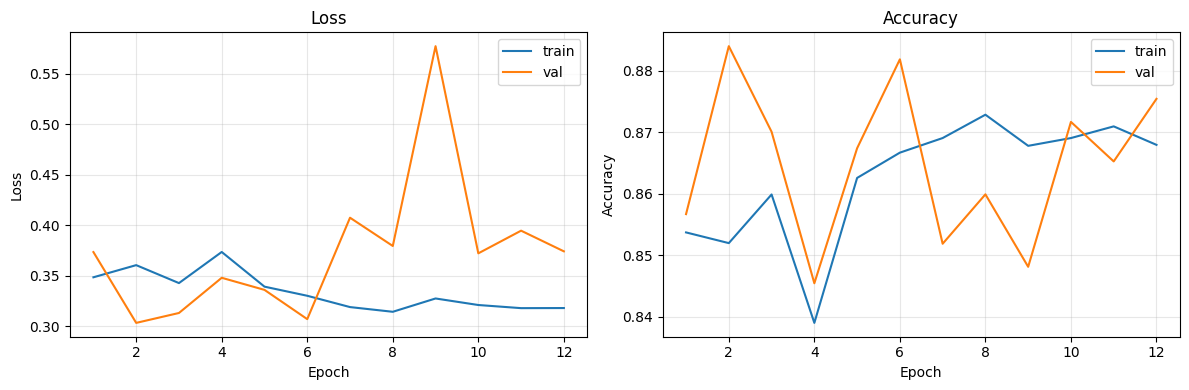

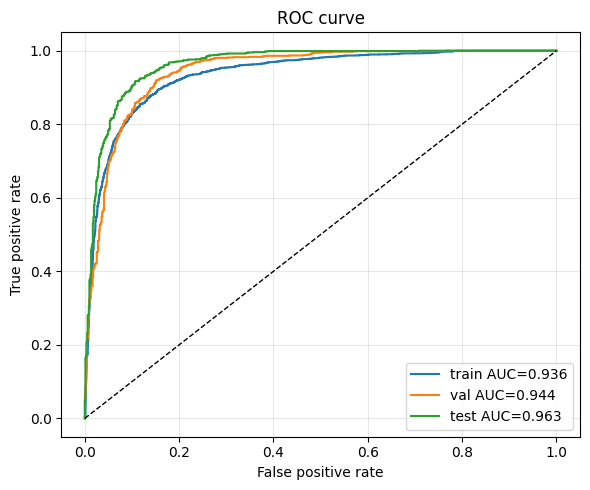

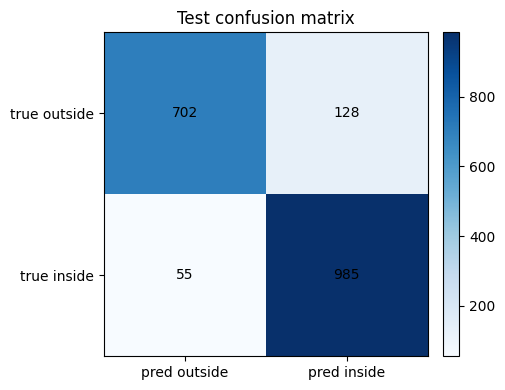

Saved plots to results/deep_patch_cnn


In [10]:
def plot_history(history):
    if not history:
        print("No training history to plot.")
        return
    epochs = [r["epoch"] for r in history]
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, [r["train_loss"] for r in history], label="train")
    plt.plot(epochs, [r["val_loss"] for r in history], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(epochs, [r["train_accuracy"] for r in history], label="train")
    plt.plot(epochs, [r["val_accuracy"] for r in history], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / "training_curves.png", dpi=160)
    plt.show()


def plot_roc(prediction_cache):
    plt.figure(figsize=(6, 5))
    for split, cache in prediction_cache.items():
        auc = split_results[split]["roc_auc"]
        plt.plot(cache["fpr"], cache["tpr"], label=f"{split} AUC={auc:.3f}")
    plt.plot([0, 1], [0, 1], "k--", linewidth=1)
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title("ROC curve")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / "roc_curve.png", dpi=160)
    plt.show()


def plot_confusion_matrix(confusion, title="Test confusion matrix"):
    mat = np.array([[confusion["tn"], confusion["fp"]], [confusion["fn"], confusion["tp"]]])
    plt.figure(figsize=(5, 4))
    plt.imshow(mat, cmap="Blues")
    plt.xticks([0, 1], ["pred outside", "pred inside"])
    plt.yticks([0, 1], ["true outside", "true inside"])
    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(mat[i, j]), ha="center", va="center", color="black")
    plt.title(title)
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "test_confusion_matrix.png", dpi=160)
    plt.show()


plot_history(history)
plot_roc(prediction_cache)
plot_confusion_matrix(split_results["test"]["confusion"])

print("Saved plots to", OUT_DIR)

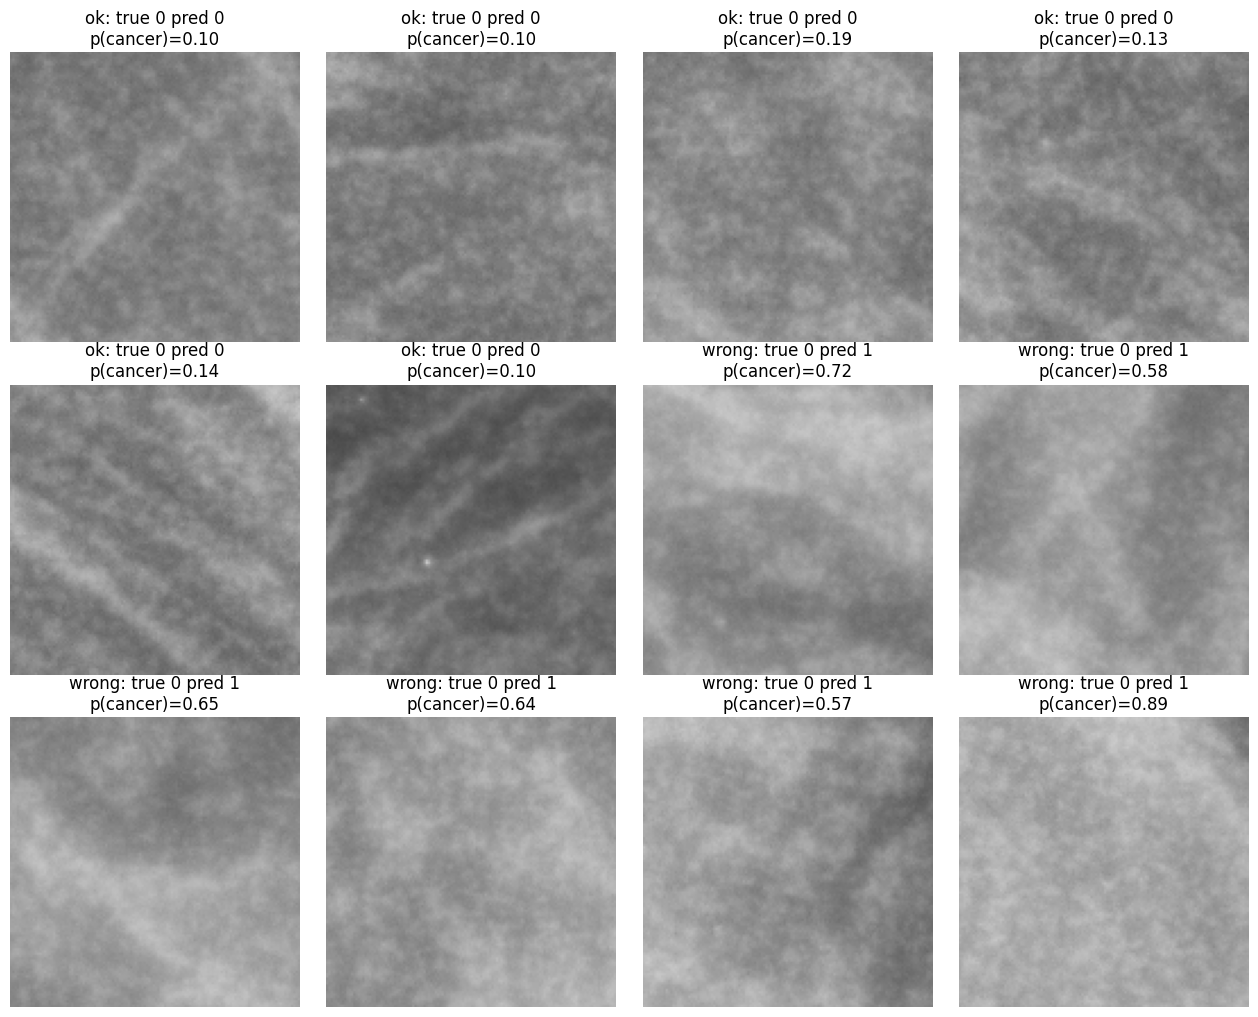

In [11]:
@torch.no_grad()
def show_prediction_examples(model, dataset, max_items=12):
    loader = make_loader(dataset, batch_size=64, shuffle=False)
    rows = []
    offset = 0
    model.eval()
    for x, y in loader:
        logits = model(x.to(device))
        probs = torch.softmax(logits, dim=1)[:, 1].cpu()
        preds = logits.argmax(dim=1).cpu()
        for j in range(x.size(0)):
            rows.append({
                "idx": offset + j,
                "x": x[j],
                "true": int(y[j]),
                "pred": int(preds[j]),
                "score": float(probs[j]),
                "correct": int(y[j]) == int(preds[j]),
            })
        offset += x.size(0)
    correct = [r for r in rows if r["correct"]][: max_items // 2]
    wrong = [r for r in rows if not r["correct"]][: max_items - len(correct)]
    selected = correct + wrong
    if not selected:
        print("No examples available.")
        return
    cols = 4
    plot_rows = math.ceil(len(selected) / cols)
    plt.figure(figsize=(cols * 3.2, plot_rows * 3.4))
    for i, r in enumerate(selected, start=1):
        img = denormalize_tensor(r["x"]).permute(1, 2, 0).numpy()
        plt.subplot(plot_rows, cols, i)
        plt.imshow(img)
        status = "ok" if r["correct"] else "wrong"
        plt.title(f"{status}: true {r['true']} pred {r['pred']}\np(cancer)={r['score']:.2f}")
        plt.axis("off")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "test_prediction_examples.png", dpi=160)
    plt.show()


show_prediction_examples(model, test_ds, max_items=12)

## Optional ResNet Transfer Learning

This section is intentionally optional. It requires `torchvision`. In the current environment used to create this notebook, `torchvision` was not installed, so the cell below skips cleanly unless `RUN_RESNET_TRANSFER = True` and `torchvision` imports successfully.

RUN_RESNET_TRANSFER is False; optional ResNet section skipped.


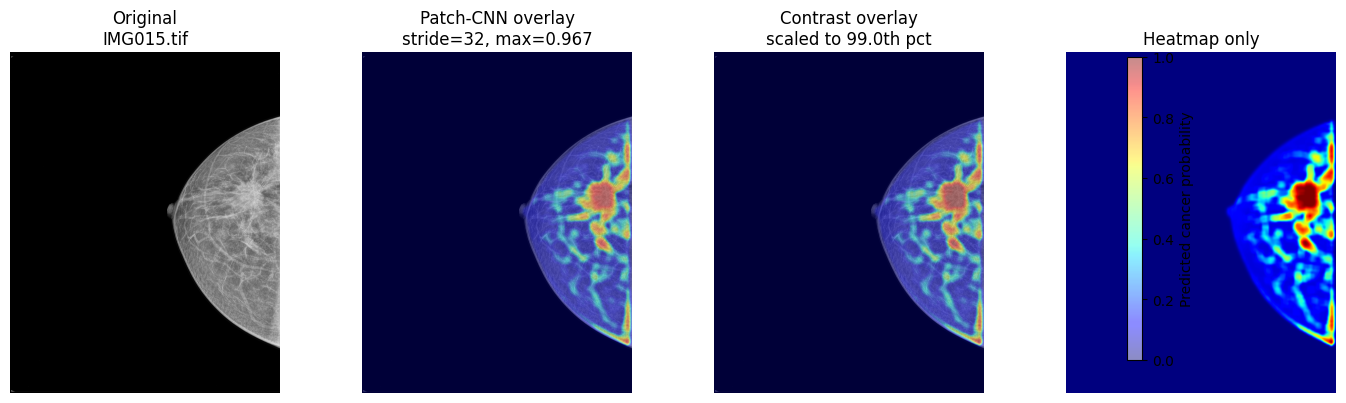

Whole-image heatmap grid size: (188, 149) with stride=32
Saved heatmap figure: results/deep_patch_cnn/heatmaps/IMG015_patch_cnn_heatmap.png
Saved probability map: results/deep_patch_cnn/heatmaps/IMG015_patch_cnn_prob_map.npy
Saved probability grid: results/deep_patch_cnn/heatmaps/IMG015_patch_cnn_prob_grid.npy


In [12]:
if RUN_RESNET_TRANSFER:
    try:
        from torchvision import models
        from torchvision.models import ResNet18_Weights
    except Exception as exc:
        print("Skipping ResNet transfer learning because torchvision is unavailable:", repr(exc))
    else:
        weights = ResNet18_Weights.DEFAULT
        resnet = models.resnet18(weights=weights)
        in_features = resnet.fc.in_features
        resnet.fc = nn.Linear(in_features, 2)
        resnet = resnet.to(device)
        print("ResNet18 is ready. Reuse train_model(resnet, train_loader, val_loader, ...) if you want to train it.")
else:
    print("RUN_RESNET_TRANSFER is False; optional ResNet section skipped.")


# Whole-image heatmap from patch CNN probabilities.
FULL_IMAGE_PATH = Path("data/TIFF Images/all/IMG015.tif")
HEATMAP_OUT_DIR = OUT_DIR / "heatmaps"
HEATMAP_OUT_DIR.mkdir(parents=True, exist_ok=True)

HEATMAP_STRIDE = 32
HEATMAP_BATCH_SIZE = 128
HEATMAP_ROW_BLOCK = 16
HEATMAP_ALPHA = 0.45
HEATMAP_DISPLAY_PERCENTILE = 99.0
HEATMAP_MASK_THRESHOLD = 0.02
HEATMAP_SMOOTH_SIGMA = max(1.0, HEATMAP_STRIDE * 0.35)


def find_default_full_image():
    if FULL_IMAGE_PATH.exists():
        return FULL_IMAGE_PATH
    candidates = sorted((Path("data/TIFF Images/all")).glob("*.tif"))
    if candidates:
        return candidates[0]
    candidates = sorted((Path("data/TIFF Images/Malignant")).glob("*.tif"))
    if candidates:
        return candidates[0]
    raise FileNotFoundError("No full TIFF image found under data/TIFF Images/all or data/TIFF Images/Malignant")


@torch.no_grad()
def predict_patch_probability_batch(model, patch_images):
    tensors = [normalize_tensor(pil_to_rgb_tensor(patch)) for patch in patch_images]
    x = torch.stack(tensors, dim=0).to(device, non_blocking=True)
    logits = model(x)
    return torch.softmax(logits, dim=1)[:, CLASS_TO_IDX["inside"]].detach().cpu().numpy().astype(np.float32)


@torch.no_grad()
def full_image_probability_grid(model, image_rgb, patch_size=IMAGE_SIZE, stride=HEATMAP_STRIDE):
    width, height = image_rgb.size
    y_positions = list(range(0, height, stride))
    x_positions = list(range(0, width, stride))
    prob_grid = np.zeros((len(y_positions), len(x_positions)), dtype=np.float32)
    half = patch_size // 2

    model.eval()
    for row_start in range(0, len(y_positions), HEATMAP_ROW_BLOCK):
        batch_patches = []
        batch_coords = []
        for gy, y_center in enumerate(y_positions[row_start: row_start + HEATMAP_ROW_BLOCK], start=row_start):
            for gx, x_center in enumerate(x_positions):
                left = int(x_center - half)
                top = int(y_center - half)
                right = left + patch_size
                bottom = top + patch_size
                patch = Image.new("RGB", (patch_size, patch_size), color=(0, 0, 0))
                crop = image_rgb.crop((max(left, 0), max(top, 0), min(right, width), min(bottom, height)))
                paste_xy = (max(0, -left), max(0, -top))
                patch.paste(crop, paste_xy)
                batch_patches.append(patch)
                batch_coords.append((gy, gx))

                if len(batch_patches) >= HEATMAP_BATCH_SIZE:
                    probs = predict_patch_probability_batch(model, batch_patches)
                    for (yy, xx), prob in zip(batch_coords, probs):
                        prob_grid[yy, xx] = prob
                    batch_patches.clear()
                    batch_coords.clear()

        if batch_patches:
            probs = predict_patch_probability_batch(model, batch_patches)
            for (yy, xx), prob in zip(batch_coords, probs):
                prob_grid[yy, xx] = prob

    return prob_grid, np.asarray(y_positions), np.asarray(x_positions)


def smooth_heatmap(prob_map, mask, sigma=HEATMAP_SMOOTH_SIGMA):
    try:
        from scipy.ndimage import gaussian_filter
    except Exception:
        return prob_map * mask
    smooth_num = gaussian_filter(prob_map * mask, sigma=float(sigma))
    smooth_den = gaussian_filter(mask.astype(np.float32), sigma=float(sigma))
    return smooth_num / np.maximum(smooth_den, 1e-6) * mask


example_path = find_default_full_image()
with Image.open(example_path) as image:
    full_image_rgb = image.convert("RGB")

prob_grid, y_grid, x_grid = full_image_probability_grid(model, full_image_rgb)
prob_map = F.interpolate(
    torch.from_numpy(prob_grid)[None, None],
    size=(full_image_rgb.height, full_image_rgb.width),
    mode="bicubic",
    align_corners=False,
)[0, 0].clamp(0, 1).cpu().numpy().astype(np.float32)

img_gray = np.asarray(full_image_rgb.convert("L"), dtype=np.float32) / 255.0
breast_mask = (img_gray > HEATMAP_MASK_THRESHOLD).astype(np.float32)
prob_map_vis = smooth_heatmap(prob_map, breast_mask)

masked_vals = prob_map_vis[breast_mask > 0]
display_hi = float(np.percentile(masked_vals, HEATMAP_DISPLAY_PERCENTILE)) if masked_vals.size else float(np.percentile(prob_map_vis, HEATMAP_DISPLAY_PERCENTILE))
display_hi = max(display_hi, 1e-6)
prob_map_display = np.clip(prob_map_vis / display_hi, 0.0, 1.0).astype(np.float32) * breast_mask

fig, axes = plt.subplots(1, 4, figsize=(18, 4.8))
axes[0].imshow(full_image_rgb)
axes[0].set_title(f"Original\n{example_path.name}")
axes[0].axis("off")

axes[1].imshow(full_image_rgb)
im = axes[1].imshow(prob_map_vis, cmap="jet", alpha=HEATMAP_ALPHA, vmin=0.0, vmax=1.0, interpolation="bilinear")
axes[1].set_title(f"Patch-CNN overlay\nstride={HEATMAP_STRIDE}, max={float(prob_map_vis.max()):.3f}")
axes[1].axis("off")

axes[2].imshow(full_image_rgb)
axes[2].imshow(prob_map_display, cmap="jet", alpha=HEATMAP_ALPHA, vmin=0.0, vmax=1.0, interpolation="bilinear")
axes[2].set_title(f"Contrast overlay\nscaled to {HEATMAP_DISPLAY_PERCENTILE:.1f}th pct")
axes[2].axis("off")

axes[3].imshow(prob_map_display, cmap="jet", vmin=0.0, vmax=1.0, interpolation="bilinear")
axes[3].set_title("Heatmap only")
axes[3].axis("off")

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.82)
cbar.set_label("Predicted cancer probability")
fig.subplots_adjust(top=0.82, wspace=0.04)
plt.show()

heatmap_fig_path = HEATMAP_OUT_DIR / f"{example_path.stem}_patch_cnn_heatmap.png"
prob_map_path = HEATMAP_OUT_DIR / f"{example_path.stem}_patch_cnn_prob_map.npy"
prob_grid_path = HEATMAP_OUT_DIR / f"{example_path.stem}_patch_cnn_prob_grid.npy"
fig.savefig(heatmap_fig_path, dpi=260, bbox_inches="tight")
np.save(prob_map_path, prob_map.astype(np.float32))
np.save(prob_grid_path, prob_grid.astype(np.float32))

print(f"Whole-image heatmap grid size: {prob_grid.shape} with stride={HEATMAP_STRIDE}")
print(f"Saved heatmap figure: {heatmap_fig_path}")
print(f"Saved probability map: {prob_map_path}")
print(f"Saved probability grid: {prob_grid_path}")

